# IEEE 39-bus illustration

The New England grid graph (coloured by bus role) + the scattered sparse
$[A_\star\,|\,B_\star]$ pattern its Laplacian induces. Writes `ieee39.{pdf,png}`
into this notebook's folder. The layout is baked from a deterministic networkx
`kamada_kawai` embedding, so the notebook needs only numpy/matplotlib.

In [1]:
import os, sys

# LaTeX on PATH for usetex (environment-specific; harmless if your TeX lives elsewhere).
tex_path = "/dss/dsshome1/07/go69lir/texlive/2026/bin/x86_64-linux"
if os.path.isdir(tex_path) and tex_path not in os.environ["PATH"]:
    os.environ["PATH"] += os.pathsep + tex_path

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from system_generator import sample_ieee39
from ieee39_data import IEEE39_BRANCHES, IEEE39_ACTUATED_BUSES

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}\usepackage{amssymb}\usepackage{bm}",
    "font.family": "serif", "font.size": 10, "savefig.bbox": "tight",
})

In [3]:
POS = {1: [0.351, -0.211], 2: [0.303, -0.225], 3: [0.217, -0.086], 4: [0.199, 0.018],
       5: [0.374, 0.058], 6: [0.457, 0.543], 7: [0.666, 0.389], 8: [0.517, -0.088],
       9: [0.504, -0.143], 10: [0.061, 0.901], 11: [0.189, 0.451], 12: [0.162, 0.413],
       13: [0.134, 0.377], 14: [0.06, 0.152], 15: [-0.044, 0.137], 16: [-0.278, -0.006],
       17: [-0.152, -0.25], 18: [0.071, -0.119], 19: [-0.328, 0.093], 20: [-0.4, 0.25],
       21: [-0.427, -0.068], 22: [-0.593, -0.064], 23: [-0.681, -0.253], 24: [-0.625, -0.264],
       25: [0.116, -0.432], 26: [0.051, -0.452], 27: [-0.092, -0.364], 28: [0.015, -0.434],
       29: [0.044, -0.484], 30: [0.375, -0.329], 31: [0.493, 0.616], 32: [0.059, 1.0],
       33: [-0.463, 0.129], 34: [-0.484, 0.337], 35: [-0.735, 0.01], 36: [-0.749, -0.283],
       37: [0.18, -0.503], 38: [0.016, -0.619], 39: [0.436, -0.194]}

GEN = set(IEEE39_ACTUATED_BUSES)
REF = 39
VERM, BLUE, GREY = "#D55E00", "#0072B2", "#bdbdbd"

A, B, supports, _ = sample_ieee39(seed=0)

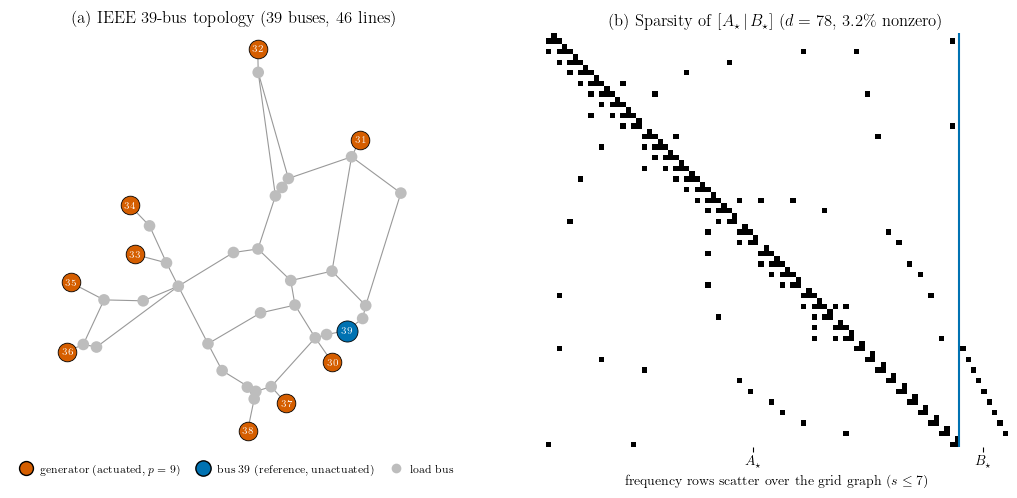

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5),
                               gridspec_kw={"width_ratios": [1.25, 1]})

# (a) grid graph
for f, t, _ in IEEE39_BRANCHES:
    (x0, y0), (x1, y1) = POS[f], POS[t]
    ax1.plot([x0, x1], [y0, y1], color="#999999", lw=0.8, zorder=1)
for bus, (x, y) in POS.items():
    if bus == REF:
        c, s, ec = BLUE, 230, "k"
    elif bus in GEN:
        c, s, ec = VERM, 180, "k"
    else:
        c, s, ec = GREY, 70, "none"
    ax1.scatter([x], [y], s=s, c=c, edgecolors=ec, linewidths=0.6, zorder=3)
    if bus in GEN or bus == REF:
        ax1.annotate(str(bus), (x, y), fontsize=7, ha="center", va="center",
                     color="white", zorder=4, fontweight="bold")
handles = [
    mlines.Line2D([], [], marker="o", ls="none", mfc=VERM, mec="k", ms=10, label="generator (actuated, $p=9$)"),
    mlines.Line2D([], [], marker="o", ls="none", mfc=BLUE, mec="k", ms=11, label="bus 39 (reference, unactuated)"),
    mlines.Line2D([], [], marker="o", ls="none", mfc=GREY, mec="none", ms=7, label="load bus"),
]
ax1.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.01),
           ncol=3, fontsize=8, frameon=False, handletextpad=0.3, columnspacing=1.0)
ax1.set_title("(a) IEEE 39-bus topology (39 buses, 46 lines)")
ax1.axis("off"); ax1.set_aspect("equal")

# (b) sparsity pattern of [A | B]
d, p = A.shape[0], B.shape[1]
mask = np.zeros((d, d + p))
mask[:, :d] = A != 0
mask[:, d:] = B != 0
ax2.imshow(mask, cmap="Greys", vmin=0, vmax=1, aspect="equal", interpolation="nearest")
ax2.axvline(d - 0.5, color=BLUE, lw=1.5)
ax2.set_xticks([d / 2 - 0.5, d + p / 2 - 0.5]); ax2.set_xticklabels(["$A_\star$", "$B_\star$"])
ax2.set_yticks([]); ax2.set_title("(b) Sparsity of $[A_\star\,|\,B_\star]$ ($d=78$, 3.2\% nonzero)")
ax2.set_xlabel("frequency rows scatter over the grid graph ($s \leq 7$)")
for sp in ax2.spines.values():
    sp.set_visible(False)
fig.tight_layout()

wrote ieee39.pdf


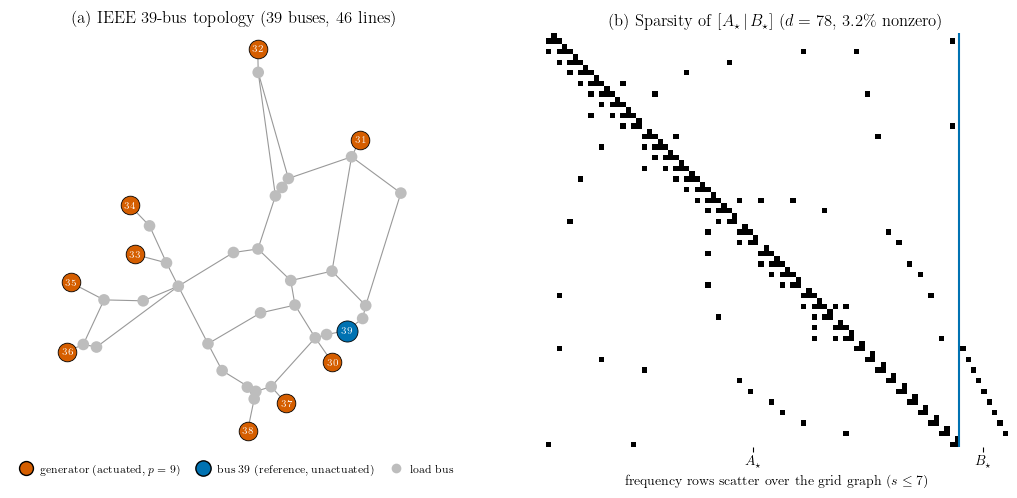

In [5]:
# saved into the notebook folder (cwd)
fig.savefig("ieee39.pdf")
fig.savefig("ieee39.png", dpi=150)
print("wrote ieee39.pdf")
fig